In [5]:
from utils.clause_visualization import test_load_and_plot_heatmap
import config
import numpy as np
from scipy.stats import entropy, spearmanr
import seaborn as sns 
import matplotlib.pyplot as plt

In [15]:
def compute_specialist_correlation_matrix(heatmap_dict):
    """
    heatmap_dict: {
        'canny':               {'pos': avg_pos, 'neg': avg_neg},
        'adaptive_gaussian':   {'pos': avg_pos, 'neg': avg_neg},
        ...
    }
    """
    from scipy.stats import spearmanr

    names = list(heatmap_dict.keys())
    n = len(names)
    corr_pos = np.zeros((n, n))
    corr_neg = np.zeros((n, n))

    for i, name_i in enumerate(names):
        for j, name_j in enumerate(names):
            rho_pos, _ = spearmanr(
                heatmap_dict[name_i]['pos'].flatten(),
                heatmap_dict[name_j]['pos'].flatten()
            )
            rho_neg, _ = spearmanr(
                heatmap_dict[name_i]['neg'].flatten(),
                heatmap_dict[name_j]['neg'].flatten()
            )
            corr_pos[i, j] = rho_pos
            corr_neg[i, j] = rho_neg

    return corr_pos, corr_neg, names

In [18]:
def plot_correlation_matrix(corr_matrix, names, title, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f",
                xticklabels=names, yticklabels=names,
                cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

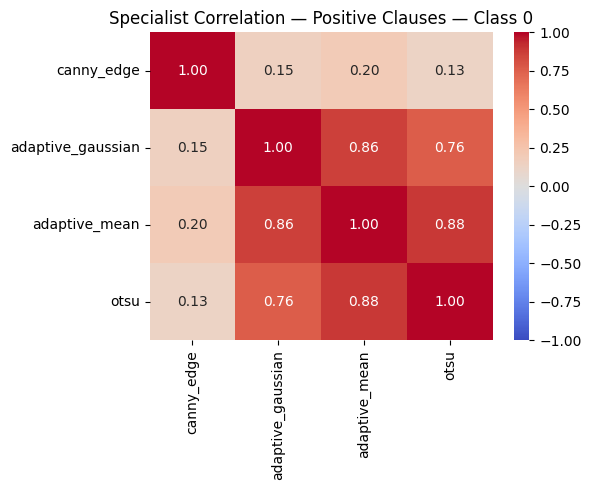

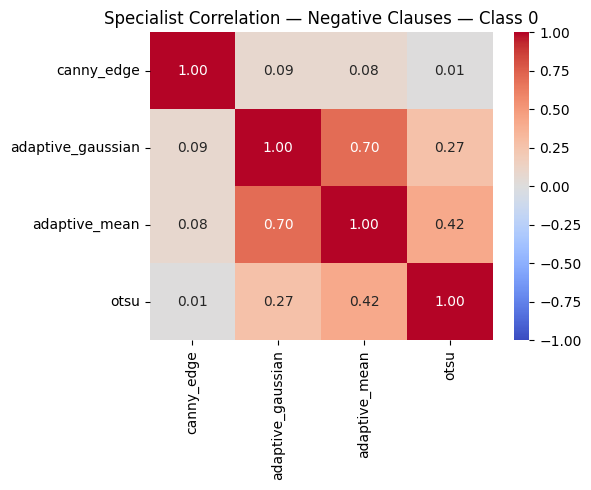

In [19]:
specialists = ['canny_edge', 'adaptive_gaussian', 'adaptive_mean', 'otsu']
classes = [0, 1]
save_dir = "saved_maps"

heatmaps = {}
for cls in classes:
    heatmaps[cls] = {}
    for spec in specialists:
        avg_pos = np.load(f"{save_dir}/global/{spec}_pos_class_{cls}.npy")
        avg_neg = np.load(f"{save_dir}/global/{spec}_neg_class_{cls}.npy")
        heatmaps[cls][spec] = {'pos': avg_pos, 'neg': avg_neg}

# now use directly
corr_pos, corr_neg, names = compute_specialist_correlation_matrix(heatmaps[0])

plot_correlation_matrix(corr_pos, names, "Specialist Correlation — Positive Clauses — Class 0")
plot_correlation_matrix(corr_neg, names, "Specialist Correlation — Negative Clauses — Class 0")


In [21]:
from scipy.stats import spearmanr

def compute_class_separability(heatmaps, specialist, polarity='pos'):
    """
    Compares heatmaps of class 0 vs class 1 for the same specialist.
    Low correlation means specialist learned different patterns per class.
    """
    map_class0 = heatmaps[0][specialist][polarity].flatten()
    map_class1 = heatmaps[1][specialist][polarity].flatten()
    rho, pval = spearmanr(map_class0, map_class1)
    return rho, pval

compute_class_separability(heatmaps, 'canny_edge', 'pos')
compute_class_separability(heatmaps, 'canny_edge', 'neg')

(0.3488842351216413, 7.397195388594851e-24)

In [22]:
from scipy.ndimage import center_of_mass
from scipy.stats import entropy

def compute_heatmap_metrics(avg_pos, avg_neg):
    metrics = {}
    
    def spatial_entropy(heatmap):
        flat = np.abs(heatmap).flatten()
        flat = flat / (flat.sum() + 1e-10)
        return entropy(flat)
    
    def coverage(heatmap):
        threshold = 0.1 * np.abs(heatmap).max()
        return (np.abs(heatmap) > threshold).mean()
    
    # how spread out are activations
    metrics['entropy_pos'] = spatial_entropy(avg_pos)
    metrics['entropy_neg'] = spatial_entropy(avg_neg)
    
    # what fraction of pixels are meaningfully active
    metrics['coverage_pos'] = coverage(avg_pos)
    metrics['coverage_neg'] = coverage(avg_neg)
    
    # where is the center of activation mass
    metrics['com_pos'] = center_of_mass(np.clip(avg_pos, 0, None))
    metrics['com_neg'] = center_of_mass(np.clip(avg_neg, 0, None))
    
    # total activation strength
    metrics['mass_pos'] = np.abs(avg_pos).sum()
    metrics['mass_neg'] = np.abs(avg_neg).sum()
    
    return metrics


compute_heatmap_metrics(heatmaps[0]['canny_edge']['pos'], heatmaps[0]['canny_edge']['neg'])

{'entropy_pos': 6.400131292823447,
 'entropy_neg': 6.344352094056564,
 'coverage_pos': 0.8035714285714286,
 'coverage_neg': 0.7104591836734694,
 'com_pos': (16.74521978021978, 10.8939010989011),
 'com_neg': (17.786177895602894, 15.397355029405492),
 'mass_pos': 81780.71428571429,
 'mass_neg': 44500.28571428571}

# Canny Edge Detection 

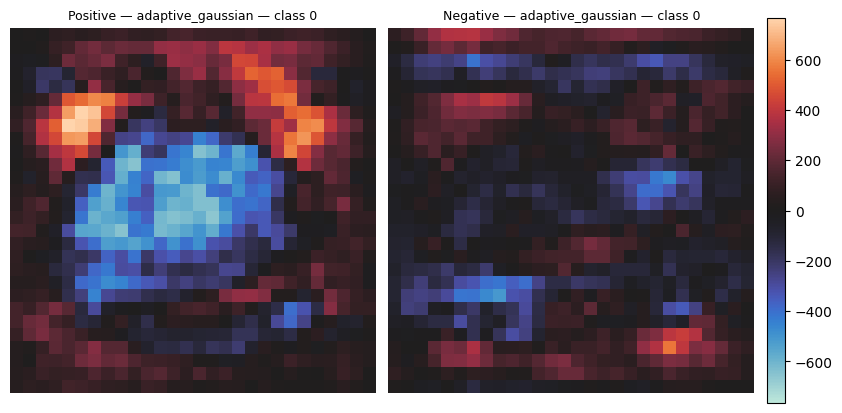

pos shape: (28, 28), min: -664.17, max: 765.92
neg shape: (28, 28), min: -509.00, max: 560.00


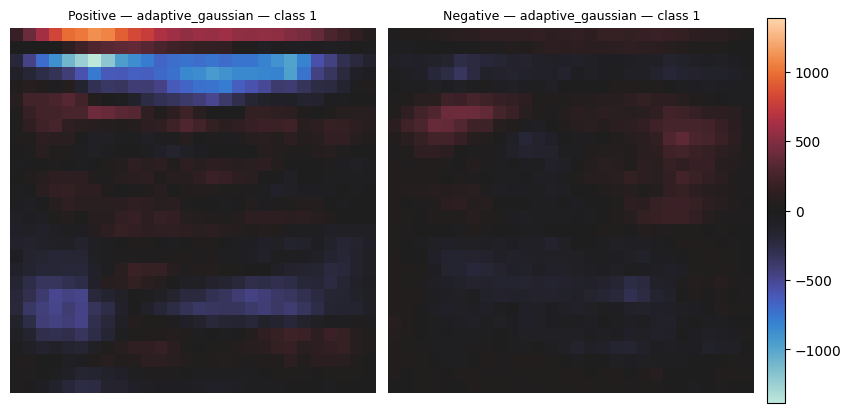

pos shape: (28, 28), min: -1387.16, max: 1109.93
neg shape: (28, 28), min: -355.60, max: 413.36


In [3]:
test_load_and_plot_heatmap(config.SAVE_MAPS_DIR, "adaptive_gaussian", target_class=0)
test_load_and_plot_heatmap(config.SAVE_MAPS_DIR, "adaptive_gaussian", target_class=1)

# Adaptive Gaussian

In [27]:
from scipy.stats import kruskal

def kruskal_wallis_across_specialists(heatmaps, target_class, polarity='pos'):
    """
    Tests whether pixel activation distributions differ across specialists.
    """
    groups = [heatmaps[target_class][spec][polarity].flatten() 
              for spec in heatmaps[target_class].keys()]
    stat, pval = kruskal(*groups)
    return stat, pval

print(kruskal_wallis_across_specialists(heatmaps, target_class=0, polarity='pos'))
print(kruskal_wallis_across_specialists(heatmaps, target_class=0, polarity='neg'))
print(kruskal_wallis_across_specialists(heatmaps, target_class=1, polarity='pos'))
print(kruskal_wallis_across_specialists(heatmaps, target_class=1, polarity='neg'))


(165.95172622497932, 9.518427516134764e-36)
(164.82511559958627, 1.6662646266256816e-35)
(385.3073844849675, 3.3692330390734106e-83)
(420.61466330091383, 7.578748451841181e-91)


In [28]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd

def pairwise_mannwhitney_matrix(heatmaps, target_class, polarity='pos', save_path=None):
    specialists = list(heatmaps[target_class].keys())
    n = len(specialists)
    
    pval_matrix = np.ones((n, n))
    stat_matrix = np.zeros((n, n))
    
    for i, spec_i in enumerate(specialists):
        for j, spec_j in enumerate(specialists):
            if i == j:
                continue
            map_i = heatmaps[target_class][spec_i][polarity].flatten()
            map_j = heatmaps[target_class][spec_j][polarity].flatten()
            stat, pval = mannwhitneyu(map_i, map_j, alternative='two-sided')
            pval_matrix[i, j] = pval
            stat_matrix[i, j] = stat

    # log transform pvalues for better visualization
    # since values are so small
    log_pval_matrix = -np.log10(pval_matrix + 1e-300)
    # set diagonal to 0
    np.fill_diagonal(log_pval_matrix, 0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # plot 1: -log10(pvalue) matrix
    sns.heatmap(log_pval_matrix, annot=True, fmt=".1f",
                xticklabels=specialists, yticklabels=specialists,
                cmap="Reds", ax=axes[0])
    axes[0].set_title(f"Pairwise Mann-Whitney\n-log10(p-value) — {polarity} — Class {target_class}")
    axes[0].tick_params(axis='x', rotation=15)

    # plot 2: significance matrix — just show significant or not
    alpha = 0.05
    sig_matrix = (pval_matrix < alpha).astype(int)
    np.fill_diagonal(sig_matrix, -1)  # mark diagonal differently

    sns.heatmap(sig_matrix, annot=True, fmt="d",
                xticklabels=specialists, yticklabels=specialists,
                cmap="RdYlGn", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title(f"Significance (1=significant, 0=not)\n— {polarity} — Class {target_class}")
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # also return a readable summary dataframe
    rows = []
    for i, spec_i in enumerate(specialists):
        for j, spec_j in enumerate(specialists):
            if i < j:  # only upper triangle to avoid duplicates
                rows.append({
                    'specialist_i': spec_i,
                    'specialist_j': spec_j,
                    'statistic': round(stat_matrix[i, j], 2),
                    'pval': pval_matrix[i, j],
                    'significant': pval_matrix[i, j] < alpha
                })
    
    return pd.DataFrame(rows)

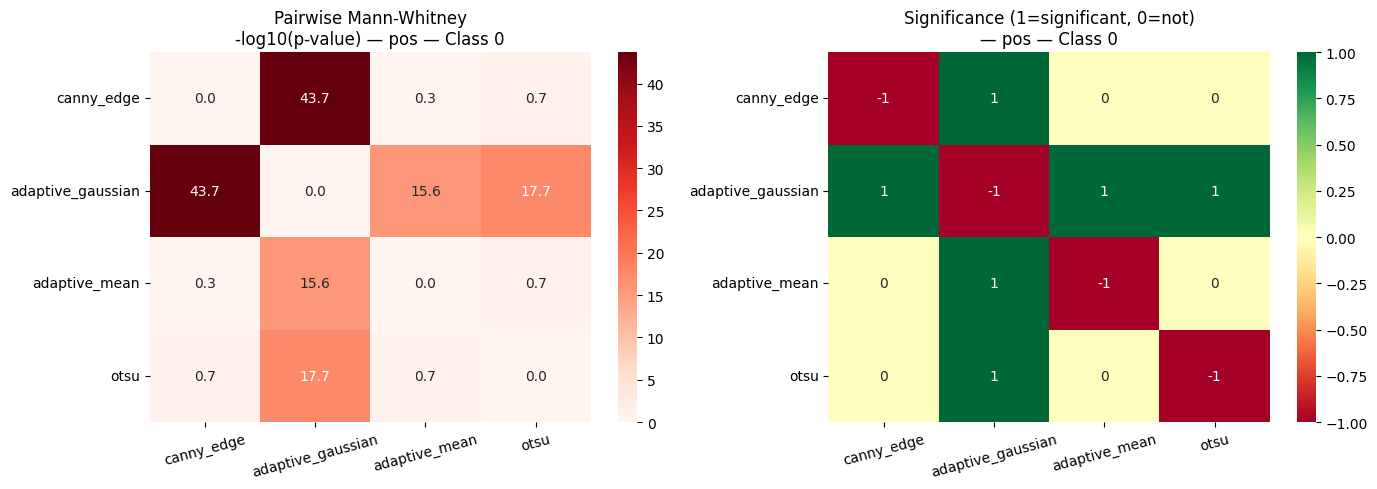

        specialist_i       specialist_j  statistic          pval  significant
0         canny_edge  adaptive_gaussian   181963.5  1.948007e-44         True
1         canny_edge      adaptive_mean   301578.5  5.213334e-01        False
2         canny_edge               otsu   295670.5  1.934916e-01        False
3  adaptive_gaussian      adaptive_mean   380893.0  2.286840e-16         True
4  adaptive_gaussian               otsu   385725.0  2.230172e-18         True
5      adaptive_mean               otsu   295313.0  1.801812e-01        False


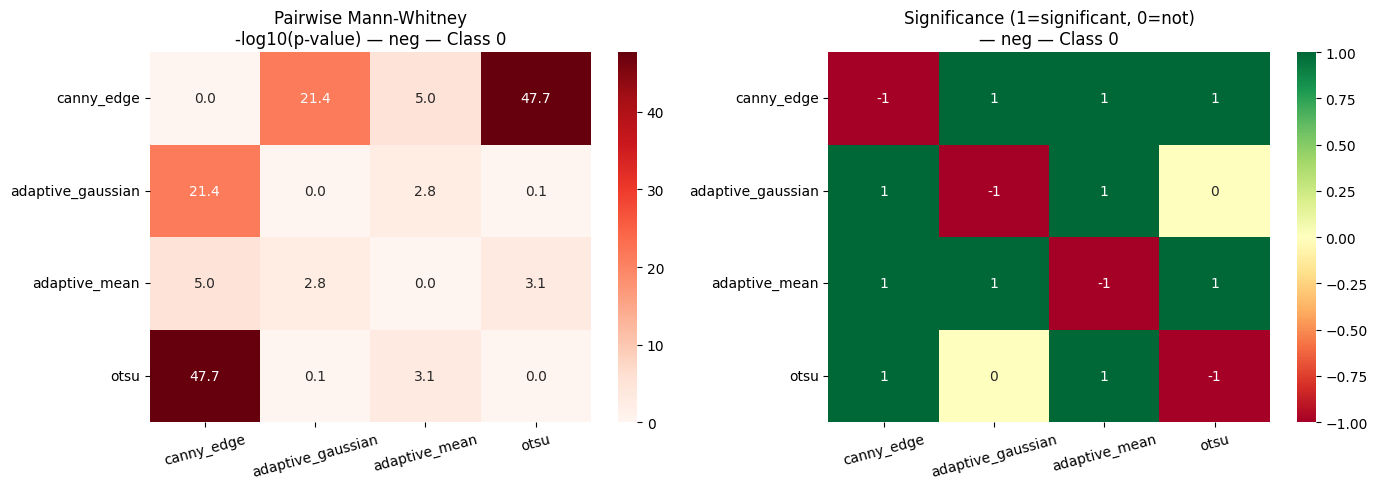

        specialist_i       specialist_j  statistic          pval  significant
0         canny_edge  adaptive_gaussian   220606.0  3.902461e-22         True
1         canny_edge      adaptive_mean   267934.5  1.111692e-05         True
2         canny_edge               otsu   176200.0  1.887776e-48         True
3  adaptive_gaussian      adaptive_mean   335444.5  1.710981e-03         True
4  adaptive_gaussian               otsu   305645.0  8.511274e-01        False
5      adaptive_mean               otsu   277050.5  7.318811e-04         True


In [29]:
# for class 0 positive clauses
df_results = pairwise_mannwhitney_matrix(
    heatmaps, target_class=0, polarity='pos')
print(df_results.to_string())

# for class 0 negative clauses
df_results = pairwise_mannwhitney_matrix(
    heatmaps, target_class=0, polarity='neg')
print(df_results.to_string())

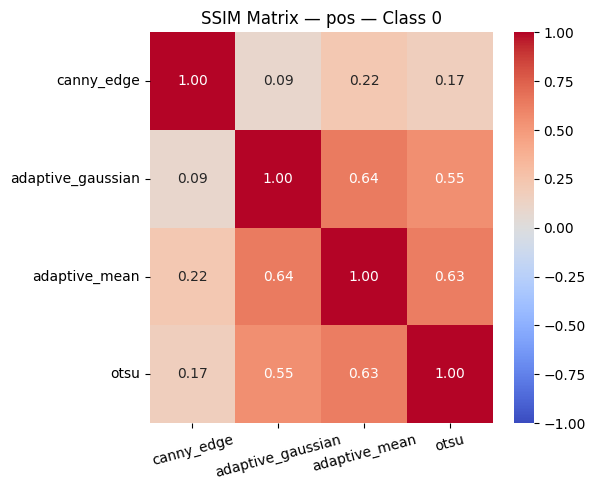

In [30]:
from skimage.metrics import structural_similarity as ssim

def compute_ssim_matrix(heatmaps, target_class, polarity='pos', save_path=None):
    specialists = list(heatmaps[target_class].keys())
    n = len(specialists)
    ssim_matrix = np.zeros((n, n))

    for i, spec_i in enumerate(specialists):
        for j, spec_j in enumerate(specialists):
            map_i = heatmaps[target_class][spec_i][polarity]
            map_j = heatmaps[target_class][spec_j][polarity]
            
            # normalize both to same range for fair comparison
            def normalize(m):
                min_val = m.min()
                max_val = m.max()
                if max_val == min_val:
                    return np.zeros_like(m)
                return (m - min_val) / (max_val - min_val)
            
            score = ssim(normalize(map_i), normalize(map_j), data_range=1.0)
            ssim_matrix[i, j] = score

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(ssim_matrix, annot=True, fmt=".2f",
                xticklabels=specialists, yticklabels=specialists,
                cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"SSIM Matrix — {polarity} — Class {target_class}")
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return ssim_matrix, specialists

# compute for class 0 positive clauses
ssim_matrix, specialists = compute_ssim_matrix(heatmaps, target_class=0, polarity='pos')